# <span style="color:red"><center>Comparative study of air quality data of Senegal(Dakar) and Cameroon(Douala)</center></span>

## DATAPREPROCESSING
#### African Institute for Mathematical Sciences, AIMS-Senegal

## Group 5 :  OPEN AIR QUALITY

* Djibril Ndour
* Farouk Zainab
* Fatou Diop
* Bayiha Jean
* Hounye DAMIEN ZINSOU

<center>Supervised by Dr Rockefeller from Stellenbosh university</center>

<center>October 31, 2024</center>

# Introduction and Context :
Air quality is a crucial environmental and public health issue, particularly in rapidly developing urban areas. This study presents a comparative analysis of air quality in two major coastal cities in Africa: Dakar, Senegal, and Douala, Cameroon. Utilizing data sourced from the OpenAQ platform, this research examines various pollutants that affect the atmospheric conditions of these regions. In Dakar, located at latitude 14.746476 and longitude -17.510441, the air quality measurements are provided by AirGradient, a recognized entity in environmental data collection. Similarly, in Douala, positioned at latitude 4.048471 and longitude 9.769506, AirGradient serves as the owner of the data collection process. By comparing the values and units of specific air quality parameters, this study aims to identify patterns, similarities, and differences in the air pollution levels of these two bustling metropolises, offering insights into the broader implications for the health of their inhabitants and the environment. The findings of this analysis could serve as a foundation for policymakers and environmental agencies to develop targeted strategies for improving air quality in these urban centers.

We chose the datasets to study based on the following criteria:

* We tried to select cities that some group members are familiar with. Our group includes members from Senegal, Benin, and Cameroon, but our data source does not provide data for Benin, and the only cities available for the other two countries are Dakar and Douala.
* We attempted to select an appropriate date range (2022–2024); however, due to a large amount of missing data, we ultimately decided to study data from September 23, 2024, to October 27, 2024.

#### Some columns of our dataframe:

* location_id : the OpenAQ location id of the station
* sensor_id : the OpenAQ sensor id of the pollutant measured
* location_name : name of location
* datetimeLocal : date and time in ISO-8601 format with timezone offset of the measurement
* datetimeUtc : Current UTC time
* latitude : decimal degree (EPSG:4326) representation of the latitude (Y) of the sensor. Minimum of -90. Maximum of 90.
* longitude : decimal degree (EPSG:4326) representation of the longitude (X) of the sensor. Minimum of -180, Maximum of 180.
* parameter : type of pollutant being reported
* unit : unit of the parameter
* value : the decimal value of the measurement

#### Parameters meaning:
* PM1: Particulate Matter with a diameter of 1 micrometer or less. These fine particles are small enough to penetrate deeply into the lungs.

* PM10: Particulate Matter with a diameter of 10 micrometers or less. PM10 includes dust, pollen, mold, and other particles.

* PM2.5: Particulate Matter with a diameter of 2.5 micrometers or less. These particles are smaller than PM10.

* Relative Humidity: The amount of moisture in the air compared to the maximum amount the air can hold at a given temperature. It is expressed as a percentage. 

* Temperature: The measure of heat in the air, usually recorded in Celsius or Fahrenheit, which influences many aspects of air quality and comfort.

* UM003: Particulate Matter with a diameter of 0.3 micrometers or less.

# I - The data transformation from raw data to a good shape

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

dakar_df = pd.read_csv('data/air-qualdakarsept_oct.csv')
dakar_df = pd.DataFrame(dakar_df)
dakar_df.sample(10)

,location_id,location_name,parameter,value,unit,datetimeUtc,datetimeLocal,timezone,latitude,longitude,country_iso,isMobile,isMonitor,owner_name,provider
2541,1531944,"Sénégal, Dakar",um003,977.033422,particles/cm³,2024-10-25T04:00:00Z,2024-10-25T04:00:00Z,Africa/Dakar,14.746476,-17.510441,NaN,NaN,NaN,Unknown Governmental Organization,AirGradient
1808,1531944,"Sénégal, Dakar",temperature,27.151719,c,2024-09-26T13:00:00Z,2024-09-26T13:00:00Z,Africa/Dakar,14.746476,-17.510441,NaN,NaN,NaN,Unknown Governmental Organization,AirGradient
906,1531944,"Sénégal, Dakar",pm25,7.488263,µg/m³,2024-09-24T21:00:00Z,2024-09-24T21:00:00Z,Africa/Dakar,14.746476,-17.510441,NaN,NaN,NaN,Unknown Governmental Organization,AirGradient
213,1531944,"Sénégal, Dakar",pm1,14.122292,µg/m³,2024-10-04T15:00:00Z,2024-10-04T15:00:00Z,Africa/Dakar,14.746476,-17.510441,NaN,NaN,NaN,Unknown Governmental Organization,AirGradient
1473,1531944,"Sénégal, Dakar",relativehumidity,84.011429,%,2024-10-03T06:00:00Z,2024-10-03T06:00:00Z,Africa/Dakar,14.746476,-17.510441,NaN,NaN,NaN,Unknown Governmental Organization,AirGradient
29,1531944,"Sénégal, Dakar",pm1,5.564467,µg/m³,2024-09-24T06:00:00Z,2024-09-24T06:00:00Z,Africa/Dakar,14.746476,-17.510441,NaN,NaN,NaN,Unknown Governmental Organization,AirGradient
1466,1531944,"Sénégal, Dakar",relativehumidity,88.198460,%,2024-10-02T23:00:00Z,2024-10-02T23:00:00Z,Africa/Dakar,14.746476,-17.510441,NaN,NaN,NaN,Unknown Governmental Organization,AirGradient
590,1531944,"Sénégal, Dakar",pm10,10.502083,µg/m³,2024-09-29T18:00:00Z,2024-09-29T18:00:00Z,Africa/Dakar,14.746476,-17.510441,NaN,NaN,NaN,Unknown Governmental Organization,AirGradient
2476,1531944,"Sénégal, Dakar",um003,1438.806132,particles/cm³,2024-10-09T12:00:00Z,2024-10-09T12:00:00Z,Africa/Dakar,14.746476,-17.510441,NaN,NaN,NaN,Unknown Governmental Organization,AirGradient
1743,1531944,"Sénégal, Dakar",temperature,30.097163,c,2024-09-23T20:00:00Z,2024-09-23T20:00:00Z,Africa/Dakar,14.746476,-17.510441,NaN,NaN,NaN,Unknown Governmental Organization,AirGradient


##### In this dataframe we can see the raw data of the Dakar dataframe. We will have to treate those data to obtain a good shape.

In [2]:
# Pivot the DataFrame to organize each 'parameter' as a separate column
pivoted_df = dakar_df.pivot_table(
    index=['datetimeLocal', 'location_id', 'location_name', 'latitude', 'longitude'],
    columns='parameter',
    values='value'
).reset_index()

group_dakar=pd.DataFrame(pivoted_df)

group_dakar.sample(10)

parameter,datetimeLocal,location_id,location_name,latitude,longitude,pm1,pm10,pm25,relativehumidity,temperature,um003
37,2024-09-24T14:00:00Z,1531944,"Sénégal, Dakar",14.746476,-17.510441,4.857904,8.891490,8.366087,83.649369,27.495854,1046.679449
422,2024-10-26T16:00:00Z,1531944,"Sénégal, Dakar",14.746476,-17.510441,4.289190,8.456366,7.990602,70.970456,31.469016,971.138723
38,2024-09-24T15:00:00Z,1531944,"Sénégal, Dakar",14.746476,-17.510441,7.461690,14.160024,13.346320,78.674281,29.026667,1515.996989
46,2024-09-24T23:00:00Z,1531944,"Sénégal, Dakar",14.746476,-17.510441,3.735509,7.367338,6.891180,87.363443,26.805611,870.231313
219,2024-10-04T21:00:00Z,1531944,"Sénégal, Dakar",14.746476,-17.510441,19.846827,27.983704,27.178727,83.837221,28.184404,3777.592936
366,2024-10-11T09:00:00Z,1531944,"Sénégal, Dakar",14.746476,-17.510441,10.790601,15.977593,15.452986,83.539491,27.224522,2099.408936
98,2024-09-27T03:00:00Z,1531944,"Sénégal, Dakar",14.746476,-17.510441,12.297384,19.014398,18.301922,89.200554,26.658362,2344.801615
221,2024-10-04T23:00:00Z,1531944,"Sénégal, Dakar",14.746476,-17.510441,17.081066,23.914327,23.386967,85.071583,27.945455,3173.526957
403,2024-10-25T21:00:00Z,1531944,"Sénégal, Dakar",14.746476,-17.510441,8.665486,16.107709,15.228820,83.516562,29.603382,1731.442037
362,2024-10-11T05:00:00Z,1531944,"Sénégal, Dakar",14.746476,-17.510441,2.706690,3.750949,3.678727,79.027258,26.971262,715.882210


In [3]:
group_dakar['datetimeLocal']= pd.to_datetime(group_dakar['datetimeLocal'])
group_dakar['Date']= pd.to_datetime(group_dakar['datetimeLocal'].dt.date)
group_dakar['Time'] = group_dakar['datetimeLocal'].dt.time
group_dakar.info()
group_dakar

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 431 entries, 0 to 430
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype              
---  ------            --------------  -----              
 0   datetimeLocal     431 non-null    datetime64[ns, UTC]
 1   location_id       431 non-null    int64              
 2   location_name     431 non-null    object             
 3   latitude          431 non-null    float64            
 4   longitude         431 non-null    float64            
 5   pm1               431 non-null    float64            
 6   pm10              431 non-null    float64            
 7   pm25              431 non-null    float64            
 8   relativehumidity  431 non-null    float64            
 9   temperature       431 non-null    float64            
 10  um003             431 non-null    float64            
 11  Date              431 non-null    datetime64[ns]     
 12  Time              431 non-null    object             
dtypes: da

parameter,datetimeLocal,location_id,location_name,latitude,longitude,pm1,pm10,pm25,relativehumidity,temperature,um003,Date,Time
0,2024-09-23 01:00:00+00:00,1531944,"Sénégal, Dakar",14.746476,-17.510441,8.366459,13.214907,12.811389,90.566205,27.505187,1661.293477,2024-09-23,01:00:00
1,2024-09-23 02:00:00+00:00,1531944,"Sénégal, Dakar",14.746476,-17.510441,8.810278,14.827754,14.324976,91.633804,27.414147,1745.378479,2024-09-23,02:00:00
2,2024-09-23 03:00:00+00:00,1531944,"Sénégal, Dakar",14.746476,-17.510441,8.062624,13.172670,12.675061,90.842332,27.350568,1590.203705,2024-09-23,03:00:00
3,2024-09-23 04:00:00+00:00,1531944,"Sénégal, Dakar",14.746476,-17.510441,8.645532,13.893842,13.491204,89.924038,27.283850,1682.464040,2024-09-23,04:00:00
4,2024-09-23 05:00:00+00:00,1531944,"Sénégal, Dakar",14.746476,-17.510441,6.374190,10.507662,10.029699,87.780156,27.129398,1304.404322,2024-09-23,05:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
426,2024-10-26 20:00:00+00:00,1531944,"Sénégal, Dakar",14.746476,-17.510441,8.383738,14.768686,13.946616,78.264700,30.234440,1675.722013,2024-10-26,20:00:00
427,2024-10-26 21:00:00+00:00,1531944,"Sénégal, Dakar",14.746476,-17.510441,12.028587,20.812915,19.828912,78.185078,29.939681,2295.615824,2024-10-26,21:00:00
428,2024-10-26 22:00:00+00:00,1531944,"Sénégal, Dakar",14.746476,-17.510441,8.481319,15.047477,14.247500,78.122348,29.666609,1690.791321,2024-10-26,22:00:00
429,2024-10-26 23:00:00+00:00,1531944,"Sénégal, Dakar",14.746476,-17.510441,16.518587,30.930577,27.390879,80.775789,29.471721,3380.186289,2024-10-26,23:00:00


In [4]:
douala_df = pd.read_csv('data/air_qualdoualasept_oct.csv')
douala_df = pd.DataFrame(douala_df)
douala_df.sample(10)

,location_id,location_name,parameter,value,unit,datetimeUtc,datetimeLocal,timezone,latitude,longitude,country_iso,isMobile,isMonitor,owner_name,provider
54,3075781,COLLEGE NAL,pm1,13.283333,µg/m³,2024-09-25T16:00:00Z,2024-09-25T17:00:00+01:00,Africa/Douala,4.048471,9.769506,NaN,NaN,NaN,AirGradient,AirGradient
1714,3075781,COLLEGE NAL,pm25,20.087500,µg/m³,2024-10-04T22:00:00Z,2024-10-04T23:00:00+01:00,Africa/Douala,4.048471,9.769506,NaN,NaN,NaN,AirGradient,AirGradient
3843,3075781,COLLEGE NAL,um003,760.441661,particles/cm³,2024-10-02T11:00:00Z,2024-10-02T12:00:00+01:00,Africa/Douala,4.048471,9.769506,NaN,NaN,NaN,AirGradient,AirGradient
97,3075781,COLLEGE NAL,pm1,1.604167,µg/m³,2024-09-27T11:00:00Z,2024-09-27T12:00:00+01:00,Africa/Douala,4.048471,9.769506,NaN,NaN,NaN,AirGradient,AirGradient
3698,3075781,COLLEGE NAL,um003,430.858330,particles/cm³,2024-09-25T20:00:00Z,2024-09-25T21:00:00+01:00,Africa/Douala,4.048471,9.769506,NaN,NaN,NaN,AirGradient,AirGradient
2501,3075781,COLLEGE NAL,relativehumidity,48.125000,%,2024-10-09T09:00:00Z,2024-10-09T10:00:00+01:00,Africa/Douala,4.048471,9.769506,NaN,NaN,NaN,AirGradient,AirGradient
3593,3075781,COLLEGE NAL,temperature,29.963750,c,2024-10-25T02:00:00Z,2024-10-25T03:00:00+01:00,Africa/Douala,4.048471,9.769506,NaN,NaN,NaN,AirGradient,AirGradient
3192,3075781,COLLEGE NAL,temperature,27.485000,c,2024-10-07T18:00:00Z,2024-10-07T19:00:00+01:00,Africa/Douala,4.048471,9.769506,NaN,NaN,NaN,AirGradient,AirGradient
330,3075781,COLLEGE NAL,pm1,7.312500,µg/m³,2024-10-09T22:00:00Z,2024-10-09T23:00:00+01:00,Africa/Douala,4.048471,9.769506,NaN,NaN,NaN,AirGradient,AirGradient
4043,3075781,COLLEGE NAL,um003,307.316668,particles/cm³,2024-10-12T23:00:00Z,2024-10-13T00:00:00+01:00,Africa/Douala,4.048471,9.769506,NaN,NaN,NaN,AirGradient,AirGradient


##### In this dataframe we can see the raw data of the Douala dataframe. We will have to treate those data to obtain a good shape.

In [5]:
# Pivot the DataFrame to organize each 'parameter' as a separate column
pivoted_df1 = douala_df.pivot_table(
    index=['datetimeLocal', 'location_id', 'location_name', 'latitude', 'longitude'],
    columns='parameter',
    values='value'
).reset_index()


group_douala=pd.DataFrame(pivoted_df1)
group_douala

parameter,datetimeLocal,location_id,location_name,latitude,longitude,pm1,pm10,pm25,relativehumidity,temperature,um003
0,2024-09-23T11:00:00+01:00,3075781,COLLEGE NAL,4.048471,9.769506,6.516667,19.038889,15.127778,54.322222,26.792778,524.800001
1,2024-09-23T12:00:00+01:00,3075781,COLLEGE NAL,4.048471,9.769506,0.583333,2.916667,2.254167,58.566667,28.182083,235.479165
2,2024-09-23T13:00:00+01:00,3075781,COLLEGE NAL,4.048471,9.769506,0.150000,1.380556,1.130556,57.333333,28.574445,223.355556
3,2024-09-23T14:00:00+01:00,3075781,COLLEGE NAL,4.048471,9.769506,2.279167,9.445833,8.000000,55.183333,28.263333,384.250001
4,2024-09-23T15:00:00+01:00,3075781,COLLEGE NAL,4.048471,9.769506,0.050000,0.506944,0.270833,51.912500,28.113750,164.074998
...,...,...,...,...,...,...,...,...,...,...,...
723,2024-10-26T21:00:00+01:00,3075781,COLLEGE NAL,4.048471,9.769506,16.366667,28.508333,26.262500,50.283333,30.953333,986.041672
724,2024-10-26T22:00:00+01:00,3075781,COLLEGE NAL,4.048471,9.769506,6.116667,15.808333,13.775000,49.966667,30.906666,611.095835
725,2024-10-26T23:00:00+01:00,3075781,COLLEGE NAL,4.048471,9.769506,3.933333,8.479167,7.666667,49.341667,30.796666,490.708336
726,2024-10-27T00:00:00+01:00,3075781,COLLEGE NAL,4.048471,9.769506,4.050000,9.583333,8.454167,49.000000,30.757916,494.654165


In [6]:
group_douala['datetimeLocal']=pd.to_datetime(group_douala['datetimeLocal'])
group_douala['Date']= pd.to_datetime(group_douala['datetimeLocal'].dt.date)
group_douala['Time'] = group_douala['datetimeLocal'].dt.time

group_douala
                                                                                                                                                                                                                     

parameter,datetimeLocal,location_id,location_name,latitude,longitude,pm1,pm10,pm25,relativehumidity,temperature,um003,Date,Time
0,2024-09-23 11:00:00+01:00,3075781,COLLEGE NAL,4.048471,9.769506,6.516667,19.038889,15.127778,54.322222,26.792778,524.800001,2024-09-23,11:00:00
1,2024-09-23 12:00:00+01:00,3075781,COLLEGE NAL,4.048471,9.769506,0.583333,2.916667,2.254167,58.566667,28.182083,235.479165,2024-09-23,12:00:00
2,2024-09-23 13:00:00+01:00,3075781,COLLEGE NAL,4.048471,9.769506,0.150000,1.380556,1.130556,57.333333,28.574445,223.355556,2024-09-23,13:00:00
3,2024-09-23 14:00:00+01:00,3075781,COLLEGE NAL,4.048471,9.769506,2.279167,9.445833,8.000000,55.183333,28.263333,384.250001,2024-09-23,14:00:00
4,2024-09-23 15:00:00+01:00,3075781,COLLEGE NAL,4.048471,9.769506,0.050000,0.506944,0.270833,51.912500,28.113750,164.074998,2024-09-23,15:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
723,2024-10-26 21:00:00+01:00,3075781,COLLEGE NAL,4.048471,9.769506,16.366667,28.508333,26.262500,50.283333,30.953333,986.041672,2024-10-26,21:00:00
724,2024-10-26 22:00:00+01:00,3075781,COLLEGE NAL,4.048471,9.769506,6.116667,15.808333,13.775000,49.966667,30.906666,611.095835,2024-10-26,22:00:00
725,2024-10-26 23:00:00+01:00,3075781,COLLEGE NAL,4.048471,9.769506,3.933333,8.479167,7.666667,49.341667,30.796666,490.708336,2024-10-26,23:00:00
726,2024-10-27 00:00:00+01:00,3075781,COLLEGE NAL,4.048471,9.769506,4.050000,9.583333,8.454167,49.000000,30.757916,494.654165,2024-10-27,00:00:00


In [7]:

group_douala['Date'].dt.year.unique()

#douala_df['unit'].unique()

array([2024], dtype=int32)

In [8]:
group_douala['Date'].dt.month.unique()

array([ 9, 10], dtype=int32)

In [9]:
group_dakar['Date'].dt.year.unique()

array([2024], dtype=int32)

In [10]:
group_dakar['Date'].dt.month.unique()

array([ 9, 10], dtype=int32)

In the above cells we are showing the year and month where we have data available.

In [11]:
del group_douala['location_id']
del group_douala['location_name']
del group_douala['latitude']
del group_douala['longitude']
group_douala

parameter,datetimeLocal,pm1,pm10,pm25,relativehumidity,temperature,um003,Date,Time
0,2024-09-23 11:00:00+01:00,6.516667,19.038889,15.127778,54.322222,26.792778,524.800001,2024-09-23,11:00:00
1,2024-09-23 12:00:00+01:00,0.583333,2.916667,2.254167,58.566667,28.182083,235.479165,2024-09-23,12:00:00
2,2024-09-23 13:00:00+01:00,0.150000,1.380556,1.130556,57.333333,28.574445,223.355556,2024-09-23,13:00:00
3,2024-09-23 14:00:00+01:00,2.279167,9.445833,8.000000,55.183333,28.263333,384.250001,2024-09-23,14:00:00
4,2024-09-23 15:00:00+01:00,0.050000,0.506944,0.270833,51.912500,28.113750,164.074998,2024-09-23,15:00:00
...,...,...,...,...,...,...,...,...,...
723,2024-10-26 21:00:00+01:00,16.366667,28.508333,26.262500,50.283333,30.953333,986.041672,2024-10-26,21:00:00
724,2024-10-26 22:00:00+01:00,6.116667,15.808333,13.775000,49.966667,30.906666,611.095835,2024-10-26,22:00:00
725,2024-10-26 23:00:00+01:00,3.933333,8.479167,7.666667,49.341667,30.796666,490.708336,2024-10-26,23:00:00
726,2024-10-27 00:00:00+01:00,4.050000,9.583333,8.454167,49.000000,30.757916,494.654165,2024-10-27,00:00:00


Here is the Dakar dataframe preprocessed, it is already in a good and suitable shape for our future treatments. 

In [12]:
del group_dakar['location_id']
del group_dakar['location_name']
del group_dakar['latitude']
del group_dakar['longitude']
group_dakar

parameter,datetimeLocal,pm1,pm10,pm25,relativehumidity,temperature,um003,Date,Time
0,2024-09-23 01:00:00+00:00,8.366459,13.214907,12.811389,90.566205,27.505187,1661.293477,2024-09-23,01:00:00
1,2024-09-23 02:00:00+00:00,8.810278,14.827754,14.324976,91.633804,27.414147,1745.378479,2024-09-23,02:00:00
2,2024-09-23 03:00:00+00:00,8.062624,13.172670,12.675061,90.842332,27.350568,1590.203705,2024-09-23,03:00:00
3,2024-09-23 04:00:00+00:00,8.645532,13.893842,13.491204,89.924038,27.283850,1682.464040,2024-09-23,04:00:00
4,2024-09-23 05:00:00+00:00,6.374190,10.507662,10.029699,87.780156,27.129398,1304.404322,2024-09-23,05:00:00
...,...,...,...,...,...,...,...,...,...
426,2024-10-26 20:00:00+00:00,8.383738,14.768686,13.946616,78.264700,30.234440,1675.722013,2024-10-26,20:00:00
427,2024-10-26 21:00:00+00:00,12.028587,20.812915,19.828912,78.185078,29.939681,2295.615824,2024-10-26,21:00:00
428,2024-10-26 22:00:00+00:00,8.481319,15.047477,14.247500,78.122348,29.666609,1690.791321,2024-10-26,22:00:00
429,2024-10-26 23:00:00+00:00,16.518587,30.930577,27.390879,80.775789,29.471721,3380.186289,2024-10-26,23:00:00


Here is the Douala dataframe preprocessed, it is already in a good and suitable shape. 

For our 2 datasets, we selected the following variables: pm1, pm10,	pm25, relativehumidity, temperature,	um003	

# II- A primary visualisation of our data trends

1. Hourly Air Quality Trends

Goal: Track how the air quality varies throughout the hours on different days.


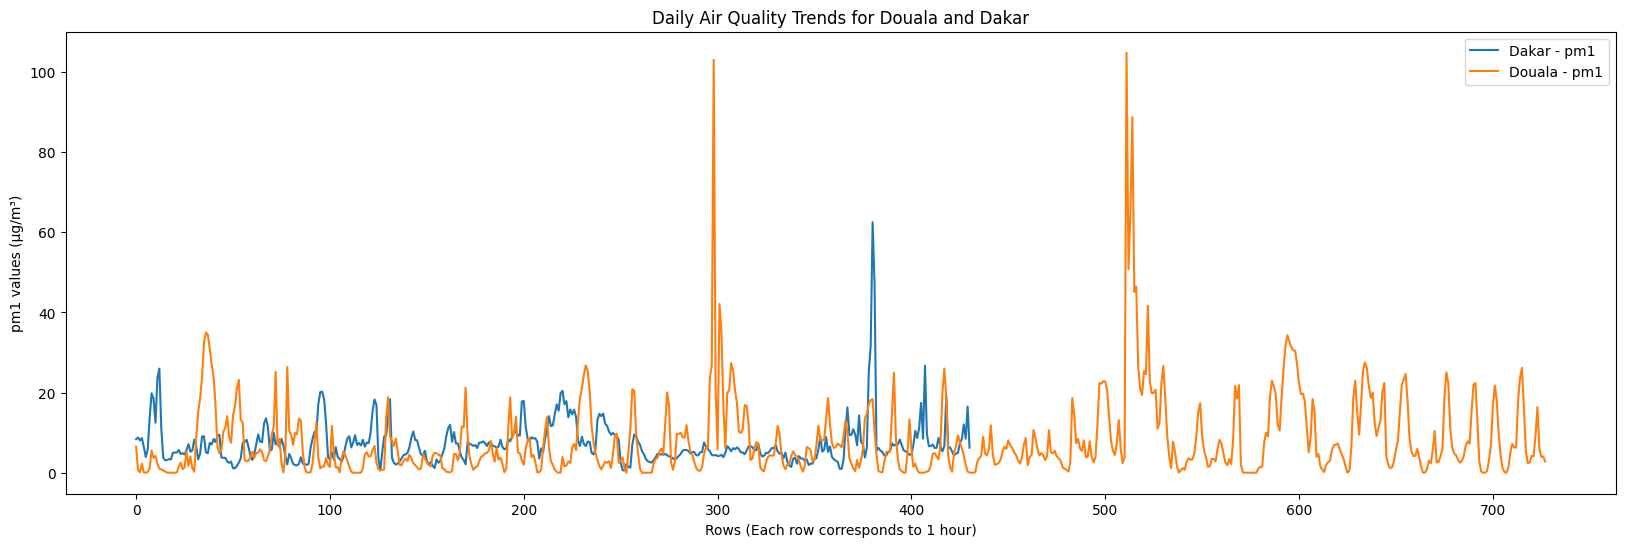

In [13]:
plt.figure(figsize=(20, 6))
plt.plot(group_dakar['pm1'], label='Dakar - pm1')
plt.plot(group_douala['pm1'], label='Douala - pm1')
plt.title('Daily Air Quality Trends for Douala and Dakar')
plt.xlabel('Rows (Each row corresponds to 1 hour)')
plt.ylabel('pm1 values (µg/m³)')
plt.legend()
plt.show()


For pm10

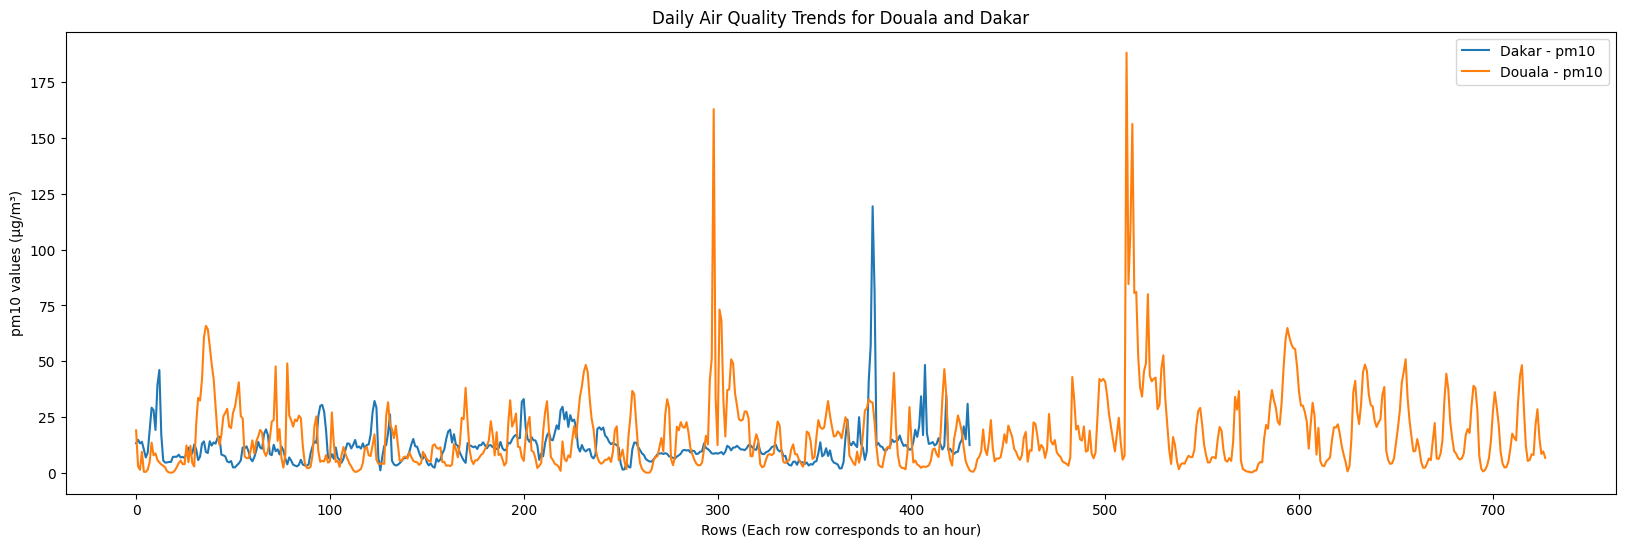

In [14]:
plt.figure(figsize=(20, 6))
plt.plot(group_dakar['pm10'], label='Dakar - pm10')
plt.plot(group_douala['pm10'], label='Douala - pm10')
plt.title('Daily Air Quality Trends for Douala and Dakar')
plt.xlabel('Rows (Each row corresponds to an hour)')
plt.ylabel('pm10 values (µg/m³)')
plt.legend()
plt.show()

For pm25

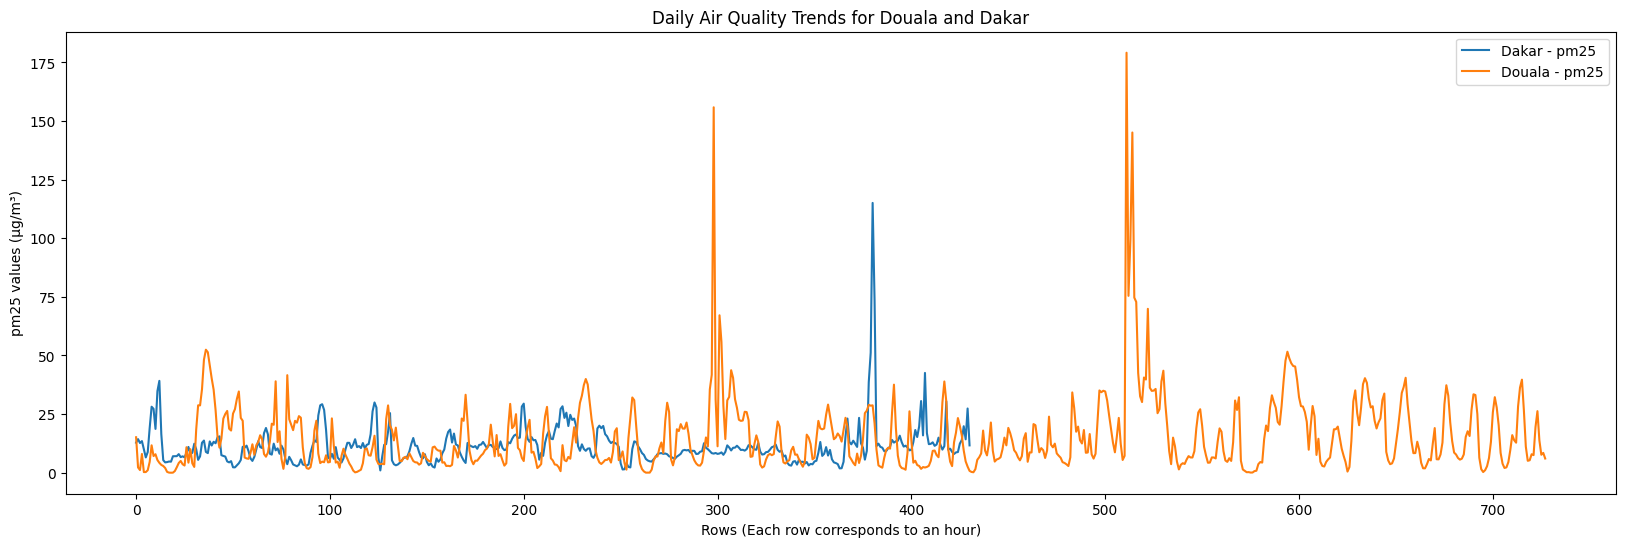

In [15]:
plt.figure(figsize=(20, 6))
plt.plot(group_dakar['pm25'], label='Dakar - pm25')
plt.plot(group_douala['pm25'], label='Douala - pm25')
plt.title('Daily Air Quality Trends for Douala and Dakar')
plt.xlabel('Rows (Each row corresponds to an hour)')
plt.ylabel('pm25 values (µg/m³)')
plt.legend()
plt.show()

For Humidity

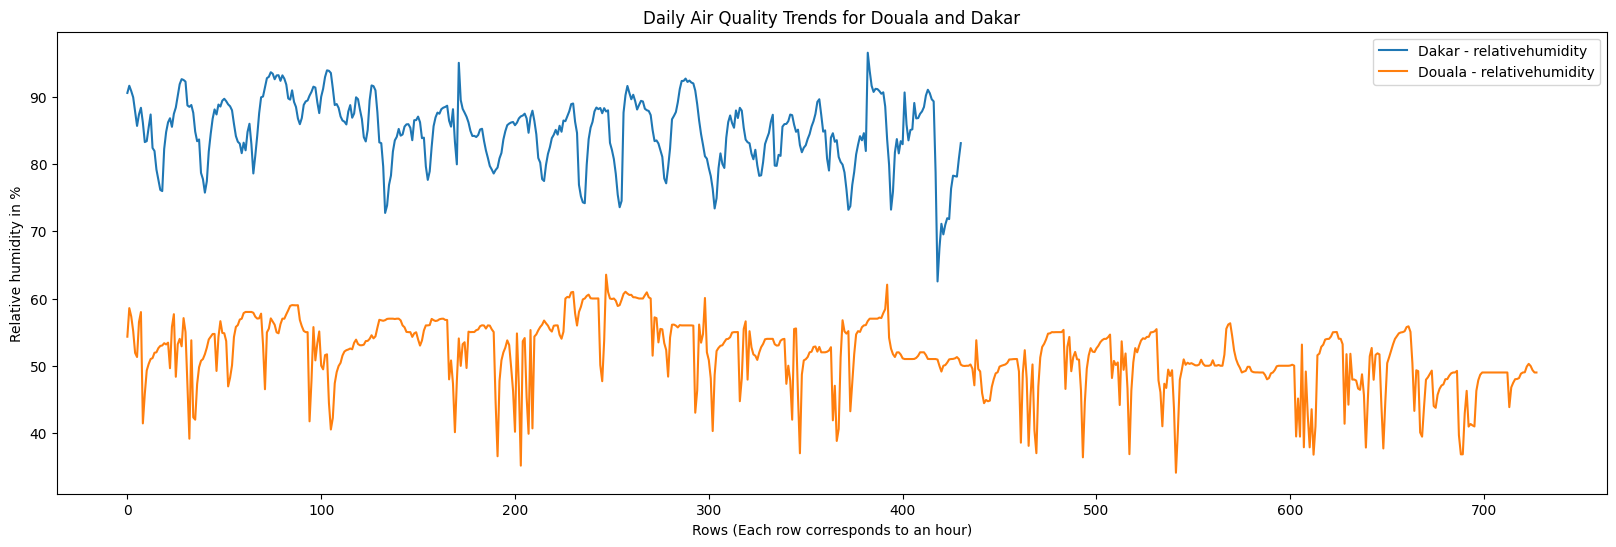

In [16]:
plt.figure(figsize=(20, 6))
plt.plot(group_dakar['relativehumidity'], label='Dakar - relativehumidity')
plt.plot(group_douala['relativehumidity'], label='Douala - relativehumidity')
plt.title('Daily Air Quality Trends for Douala and Dakar')
plt.xlabel('Rows (Each row corresponds to an hour)')
plt.ylabel('Relative humidity in %')
plt.legend()
plt.show()

For Temperature

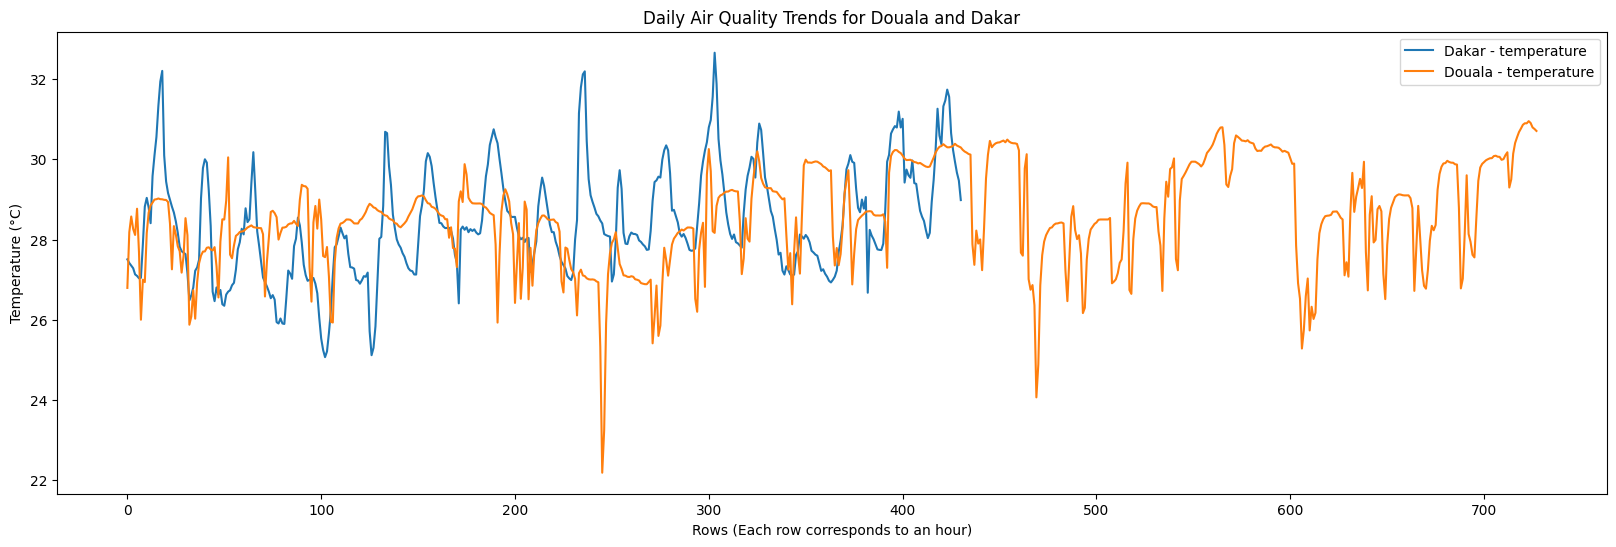

In [17]:
plt.figure(figsize=(20, 6))
plt.plot(group_dakar['temperature'], label='Dakar - temperature')
plt.plot(group_douala['temperature'], label='Douala - temperature')
plt.title('Daily Air Quality Trends for Douala and Dakar')
plt.xlabel('Rows (Each row corresponds to an hour)')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.show()

For um003

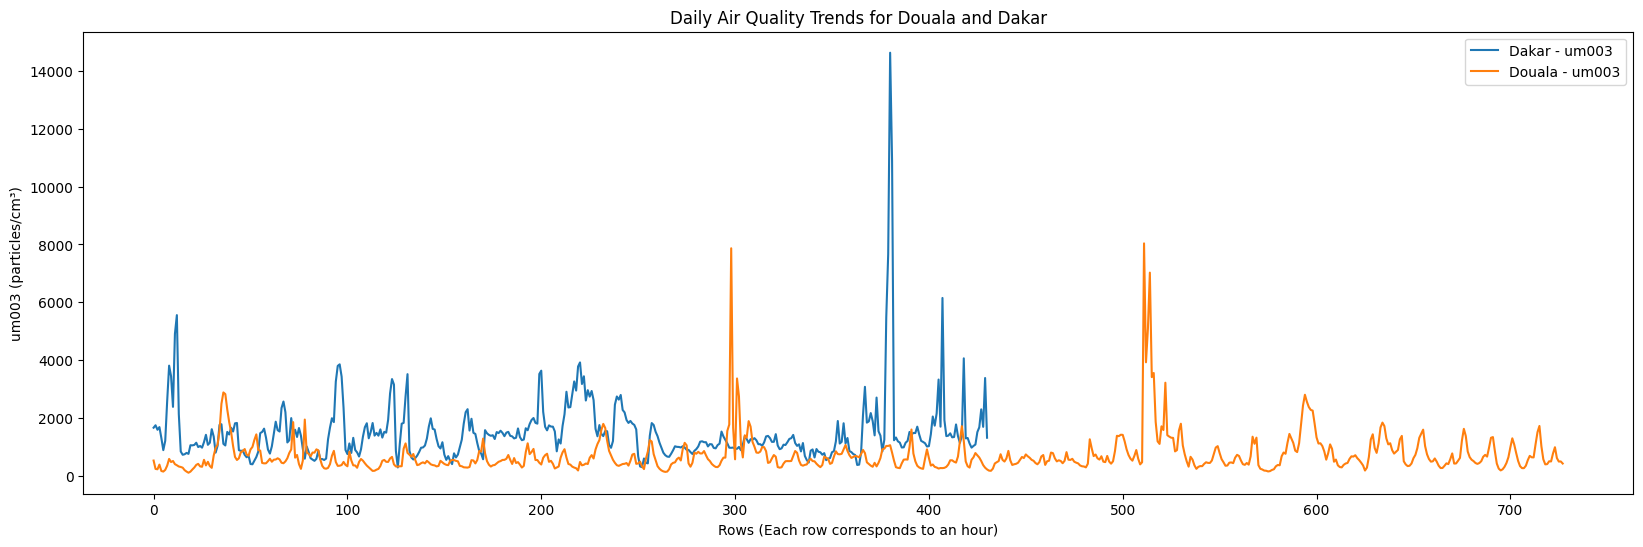

In [18]:
plt.figure(figsize=(20, 6))
plt.plot(group_dakar['um003'], label='Dakar - um003')
plt.plot(group_douala['um003'], label='Douala - um003')
plt.title('Daily Air Quality Trends for Douala and Dakar')
plt.xlabel('Rows (Each row corresponds to an hour)')
plt.ylabel('um003 (particles/cm³)')
plt.legend()
plt.show()

### ***Observation*** : In all those graphs we can see that the values of our parameters are fluctuating and that a large amount of data are missing in our Dakar dataset even if the datas are collected in the same daterange.

# III - Descriptive Statistics for Douala

1) The daily air parameters average

In [19]:
douala_group_date = group_douala.groupby('Date')[['pm1','pm10','pm25','relativehumidity','temperature','um003']].mean()
douala_group_date

parameter,pm1,pm10,pm25,relativehumidity,temperature,um003
Date,,,,,,
2024-09-23,2.125962,6.199466,5.313141,52.378312,27.845940,350.447222
2024-09-24,6.401452,13.520712,11.310264,51.205161,27.982612,627.133509
2024-09-25,13.363476,26.508466,23.096925,53.340493,27.957859,1001.717842
2024-09-26,8.141725,18.988368,16.495081,56.401100,28.223738,729.066030
2024-09-27,3.712847,9.427604,8.345370,51.867535,28.086290,464.148898
2024-09-28,3.802083,8.799479,8.014062,53.493229,28.578055,456.411111
2024-09-29,3.415220,8.355787,7.597801,55.719618,28.682176,459.593287
2024-09-30,4.335069,10.563542,9.546007,53.392535,28.684618,501.202953
2024-10-01,6.388426,15.088889,13.334568,52.343827,28.550316,603.204552


2. The air parameters total averages for our dataset

In [20]:
douala_total_average = douala_group_date.mean()
douala_total_average

parameter
pm1                   7.930951
pm10                 16.555641
pm25                 14.672369
relativehumidity     51.802316
temperature          28.585750
um003               701.009563
dtype: float64

3) The daily air parameters median

In [21]:
douala_group_date_median = group_douala.groupby('Date')[['pm1','pm10','pm25','relativehumidity','temperature','um003']].median()
douala_group_date_median

parameter,pm1,pm10,pm25,relativehumidity,temperature,um003
Date,,,,,,
2024-09-23,1.208333,4.908333,4.616667,51.912500,28.160833,362.695834
2024-09-24,1.210417,4.104167,3.800000,52.920833,28.230833,329.952084
2024-09-25,11.835417,25.393750,23.225000,54.289583,27.807708,861.625692
2024-09-26,6.323611,18.631250,15.143750,57.029167,28.299999,615.086114
2024-09-27,2.137500,6.581250,5.710417,52.520833,28.366666,387.972917
2024-09-28,2.010417,5.162500,4.810417,53.322916,28.510833,372.110415
2024-09-29,3.241667,7.031250,6.514583,56.000000,28.595625,447.470834
2024-09-30,3.497917,7.489583,6.889583,55.016667,28.783125,456.141671
2024-10-01,5.020833,13.389583,11.422917,54.395833,28.768541,548.699304


4. The air parameters total medians for our dataset

In [22]:
douala_total_median = douala_group_date_median.median()
douala_total_median

parameter
pm1                   4.845833
pm10                 11.683333
pm25                 10.194792
relativehumidity     52.400000
temperature          28.641563
um003               541.933334
dtype: float64

In [23]:
douala_total_median = douala_group_date_median.median()
douala_total_median

parameter
pm1                   4.845833
pm10                 11.683333
pm25                 10.194792
relativehumidity     52.400000
temperature          28.641563
um003               541.933334
dtype: float64

In [24]:
douala_pm1_greater_than_median = douala_group_date_median[douala_group_date_median['pm1'] > 4.845833]
douala_pm1_greater_than_median['pm1'].reset_index()

,Date,pm1
0,2024-09-25,11.835417
1,2024-09-26,6.323611
2,2024-10-01,5.020833
3,2024-10-07,9.266667
4,2024-10-08,6.289583
5,2024-10-09,7.302083
6,2024-10-11,7.100000
7,2024-10-15,4.852083
8,2024-10-17,21.885417
9,2024-10-18,5.025000


In [25]:
douala_pm10_greater_than_median = douala_group_date_median[douala_group_date_median['pm10'] > 11.683333]
douala_pm10_greater_than_median['pm10'].reset_index()

,Date,pm10
0,2024-09-25,25.393750
1,2024-09-26,18.631250
2,2024-10-01,13.389583
3,2024-10-03,14.406944
4,2024-10-07,20.370833
5,2024-10-08,16.456250
6,2024-10-09,15.491666
7,2024-10-11,18.120833
8,2024-10-15,11.858333
9,2024-10-17,39.525000


5) The daily air parameters standard deviation

In [26]:
douala_group_date_std = group_douala.groupby('Date')[['pm1','pm10','pm25','relativehumidity','temperature','um003']].std().std()
douala_group_date_std

parameter
pm1                   5.267336
pm10                  8.576108
pm25                  7.927275
relativehumidity      1.795139
temperature           0.436193
um003               412.213342
dtype: float64

In [27]:
douala_total_average

parameter
pm1                   7.930951
pm10                 16.555641
pm25                 14.672369
relativehumidity     51.802316
temperature          28.585750
um003               701.009563
dtype: float64

6. The maximum and minimum values for each air parameter

In [28]:
douala_group_date_max = group_douala.groupby('Date')[['pm1','pm10','pm25','relativehumidity','temperature','um003']].max()
douala_group_date_max

parameter,pm1,pm10,pm25,relativehumidity,temperature,um003
Date,,,,,,
2024-09-23,6.516667,19.038889,15.127778,58.566667,28.852083,580.970833
2024-09-24,35.012500,65.824999,52.466667,57.666667,29.023750,2880.950033
2024-09-25,34.437500,64.304167,51.387500,57.833333,30.049583,2822.862528
2024-09-26,26.445833,49.029166,41.608334,58.904167,28.717084,1942.579178
2024-09-27,12.983333,27.058333,23.466666,59.016667,29.364999,876.637497
2024-09-28,18.829167,31.616667,28.716667,56.833333,28.891249,1118.016668
2024-09-29,8.550000,21.091667,19.229167,57.000000,29.100000,752.308334
2024-09-30,21.229167,38.091667,33.250000,57.000000,29.880000,1284.666677
2024-10-01,18.808333,32.525000,29.358333,56.016667,29.253333,1121.966660


In [29]:
douala_group_date_min = group_douala.groupby('Date')[['pm1','pm10','pm25','relativehumidity','temperature','um003']].min()
douala_group_date_min

parameter,pm1,pm10,pm25,relativehumidity,temperature,um003
Date,,,,,,
2024-09-23,0.000000,0.425000,0.270833,41.429167,25.999167,144.287502
2024-09-24,0.000000,0.054167,0.000000,39.154167,25.875000,104.141668
2024-09-25,2.841667,6.558333,5.929167,46.933333,26.554166,427.845838
2024-09-26,0.083333,2.333333,1.645833,46.508334,26.578333,238.012498
2024-09-27,0.050000,2.108333,1.666667,40.525000,25.930000,243.454166
2024-09-28,0.000000,0.416667,0.158333,49.966667,28.278333,166.524999
2024-09-29,0.816667,3.558333,3.441667,53.000000,28.305416,322.391665
2024-09-30,0.066667,3.008333,2.779167,40.120833,27.311250,281.024996
2024-10-01,0.116667,3.291667,3.025000,36.545833,25.927500,283.141668


In [30]:
douala_group_date_max - douala_group_date_min

parameter,pm1,pm10,pm25,relativehumidity,temperature,um003
Date,,,,,,
2024-09-23,6.516667,18.613889,14.856944,17.137500,2.852916,436.683331
2024-09-24,35.012500,65.770833,52.466667,18.512500,3.148750,2776.808365
2024-09-25,31.595834,57.745834,45.458334,10.900000,3.495417,2395.016691
2024-09-26,26.362500,46.695832,39.962500,12.395833,2.138750,1704.566680
2024-09-27,12.933333,24.950000,21.800000,18.491667,3.434999,633.183331
2024-09-28,18.829167,31.200000,28.558333,6.866666,0.612917,951.491669
2024-09-29,7.733333,17.533334,15.787500,4.000000,0.794584,429.916669
2024-09-30,21.162500,35.083334,30.470833,16.879167,2.568750,1003.641680
2024-10-01,18.691667,29.233333,26.333333,19.470834,3.325833,838.824992


7. The mods of the air parameters

In [31]:
modes = group_douala.groupby('Date')[['pm1', 'pm10', 'pm25', 'relativehumidity', 'temperature', 'um003']].apply(lambda x: x.mode().iloc[0])
douala_total_modes = modes.mode().iloc[0]
douala_total_modes

parameter
pm1                   0.000000
pm10                  0.054167
pm25                  0.000000
relativehumidity     49.000000
temperature          28.299999
um003               104.141668
Name: 0, dtype: float64

8. The skewness of the air parameters in Douala

In [32]:
douala_skewness = (douala_total_average- douala_total_modes)/douala_group_date_std
douala_skewness

parameter
pm1                 1.505685
pm10                1.924122
pm25                1.850872
relativehumidity    1.561058
temperature         0.655100
um003               1.447959
dtype: float64

***Observation:*** We can see that the skewness coefficients of the particles (pm1, pm10, pm25) and relative humidity all show a strong right skew (skweness>1), suggesting the presence of extreme values. 

## Comparison between our air parameters and the limits authorized by the World Health Organization

In [33]:
douala_group_date[douala_group_date['pm10']>=45]

parameter,pm1,pm10,pm25,relativehumidity,temperature,um003
Date,,,,,,
2024-10-17,28.766262,52.330266,47.137674,50.7614,28.094797,2145.038946


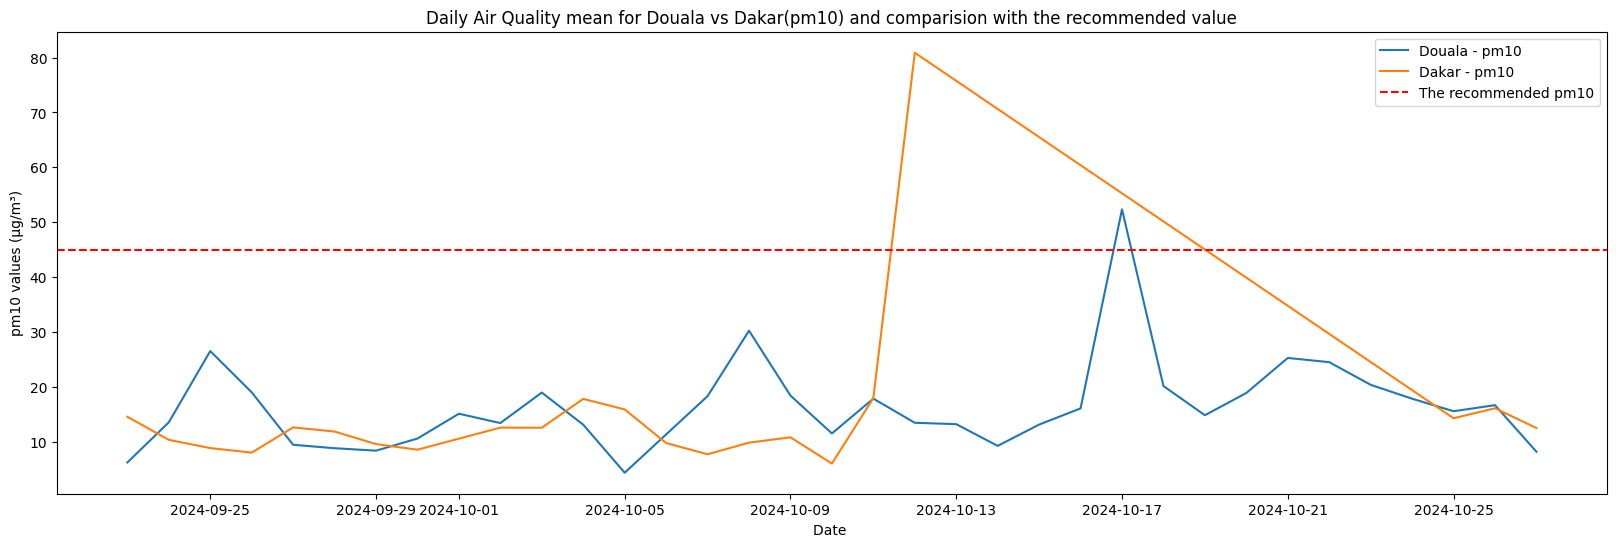

In [34]:
dakar_group_date = group_dakar.groupby('Date')[['pm1','pm10','pm25','relativehumidity','temperature','um003']].mean()
plt.figure(figsize=(20, 6))
plt.plot(douala_group_date['pm10'], label='Douala - pm10')
plt.plot(dakar_group_date['pm10'], label='Dakar - pm10')
plt.axhline(y=45, color='red', linestyle='--', label='The recommended pm10')  # Ajout de la ligne horizontale
plt.title('Daily Air Quality mean for Douala vs Dakar(pm10) and comparision with the recommended value')
plt.xlabel('Date ')
plt.ylabel('pm10 values (µg/m³)')
plt.legend()
plt.show()

For the World Health Organization, The limit for PM10 particles that is recommended is 45/m^3/day but we can see that for Douala, in the date range between september and october 2024 we have a day where the pm10 value is greater than the value recommended. So it is risky for the population.

In [35]:
douala_group_date[douala_group_date['pm25']>=15]

parameter,pm1,pm10,pm25,relativehumidity,temperature,um003
Date,,,,,,
2024-09-25,13.363476,26.508466,23.096925,53.340493,27.957859,1001.717842
2024-09-26,8.141725,18.988368,16.495081,56.401100,28.223738,729.066030
2024-10-03,9.212292,18.946111,16.305417,57.198125,27.742771,743.204582
2024-10-07,8.912103,18.291171,16.480952,54.451488,27.050605,730.815873
2024-10-08,16.424836,30.220555,27.009583,52.700467,28.314582,1329.567086
2024-10-09,9.362500,18.397454,16.655382,52.891493,29.023200,745.660995
2024-10-11,7.985427,17.840341,16.106192,50.813121,28.816355,676.244623
2024-10-17,28.766262,52.330266,47.137674,50.761400,28.094797,2145.038946
2024-10-18,9.292109,20.133418,17.406608,49.311174,28.821240,755.961858


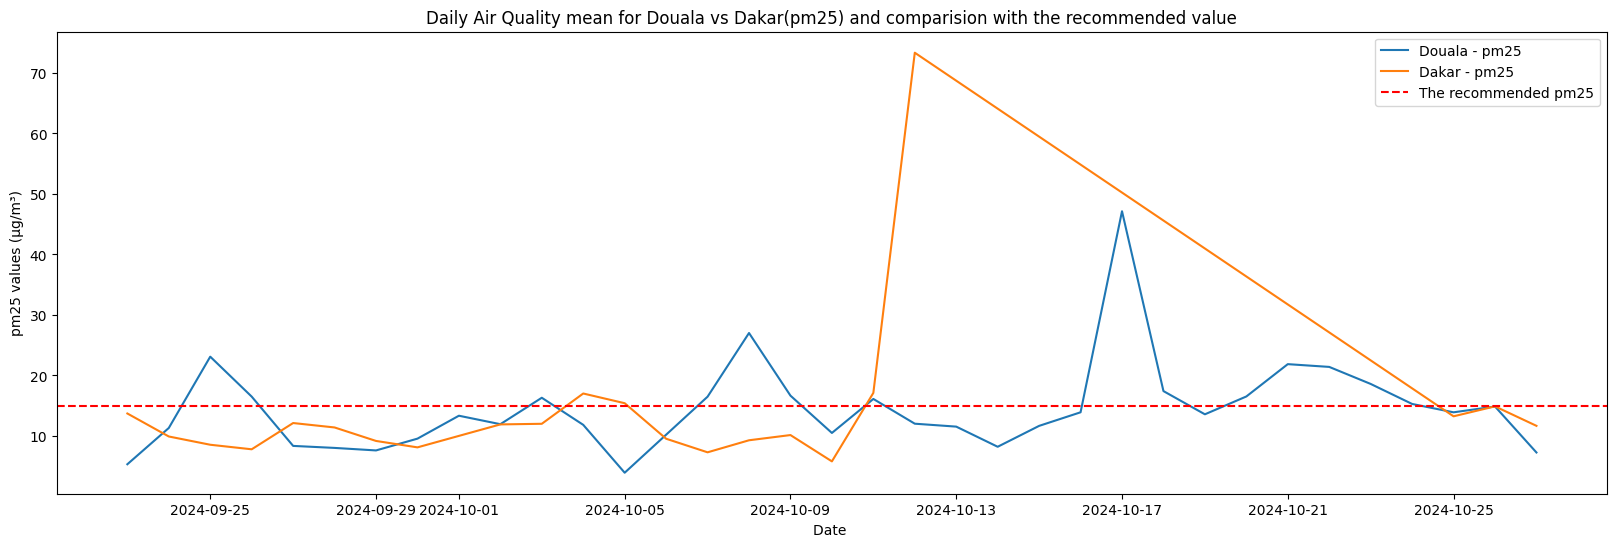

In [36]:
dakar_group_date = group_dakar.groupby('Date')[['pm1','pm10','pm25','relativehumidity','temperature','um003']].mean()
plt.figure(figsize=(20, 6))
plt.plot(douala_group_date['pm25'], label='Douala - pm25')
plt.plot(dakar_group_date['pm25'], label='Dakar - pm25')
plt.axhline(y=15, color='red', linestyle='--', label='The recommended pm25')  # Ajout de la ligne horizontale
plt.title('Daily Air Quality mean for Douala vs Dakar(pm25) and comparision with the recommended value')
plt.xlabel('Date ')
plt.ylabel('pm25 values (µg/m³)')
plt.legend()
plt.show()

For the World Health Organization, The limit for PM2.5 particles that is recommended is 15/m^3/day but we can see that for Douala, we reach this value many days in a month.

So for these two types of particles, sometimes we have values that exceed the recommended levels. This means that the health of the inhabitants of Douala City is endangered by air pollution, and this could also affect the health of tourists. Also we can observe that when the particles concentration values are greater than the recommended levels, we have high temperatures and low levels of humidity. That means that the climatic factor can influence the concentration of particles in the air. 

Other polluant source could be: 

-Road traffic (a major source of atmospheric pollutants).

-the industrial and energy sectors.

-the domestic sector (use of biomass).

-solid waste burning.

-desert dust and savannah fires.

# IV - Descriptive statistics for Dakar

1) The daily air parameters average

In [37]:
dakar_group_date = group_dakar.groupby('Date')[['pm1','pm10','pm25','relativehumidity','temperature','um003']].mean()
dakar_group_date

parameter,pm1,pm10,pm25,relativehumidity,temperature,um003
Date,,,,,,
2024-09-23,9.252022,14.527916,13.704041,84.825161,28.878517,1872.116147
2024-09-24,6.222978,10.324990,9.901886,86.010687,27.928907,1277.090083
2024-09-25,5.860663,8.824538,8.537021,85.820517,27.680688,1224.056179
2024-09-26,5.559961,7.998522,7.785672,90.766220,26.951946,1173.942930
2024-09-27,7.939202,12.593049,12.126205,89.567832,26.941064,1592.060268
2024-09-28,7.589344,11.840120,11.394902,84.110528,27.696588,1526.737272
2024-09-29,5.926093,9.551418,9.165765,85.014167,28.398498,1236.282609
2024-09-30,4.837554,8.530856,8.103218,85.341911,27.976374,1041.324387
2024-10-02,7.300790,12.552065,11.899325,90.914358,27.659772,1485.799162


2) The total air parameters average

In [38]:
dakar_total_average = dakar_group_date.mean()
dakar_total_average

parameter
pm1                    8.900955
pm10                  14.938158
pm25                  14.058376
relativehumidity      85.040676
temperature           28.411775
um003               1893.233030
dtype: float64

3) The daily air parameters median

In [39]:
dakar_group_date_median = group_dakar.groupby('Date')[['pm1','pm10','pm25','relativehumidity','temperature','um003']].median()
dakar_group_date_median

parameter,pm1,pm10,pm25,relativehumidity,temperature,um003
Date,,,,,,
2024-09-23,6.374190,10.507662,10.029699,85.663661,28.820962,1304.404322
2024-09-24,5.598495,9.116009,8.691389,87.410589,27.690426,1151.926674
2024-09-25,5.643276,8.142790,7.903947,85.970806,27.598371,1189.222020
2024-09-26,4.405139,6.622674,6.389444,91.186296,26.953756,968.923030
2024-09-27,6.715509,11.146887,10.727222,89.056844,27.070980,1368.494741
2024-09-28,5.034225,7.208719,7.036274,84.012049,27.525177,1067.856509
2024-09-29,5.746065,8.912731,8.557824,85.758291,28.365884,1203.099978
2024-09-30,4.568252,8.185498,7.772662,85.993609,28.122554,990.780485
2024-10-02,7.242970,12.357685,11.730780,89.501161,28.249047,1468.383423


4. The air parameters total medians for our dataset

In [40]:
dakar_total_median = dakar_group_date_median.median()
dakar_total_median

parameter
pm1                    6.064664
pm10                  10.827274
pm25                  10.378460
relativehumidity      85.531584
temperature           28.245894
um003               1289.787024
dtype: float64

In [41]:
dakar_pm1_greater_than_median = dakar_group_date_median[dakar_group_date_median['pm1'] > 6.064664]
dakar_pm1_greater_than_median['pm1'].reset_index()

,Date,pm1
0,2024-09-23,6.374190
1,2024-09-27,6.715509
2,2024-10-02,7.242970
3,2024-10-03,7.424244
4,2024-10-04,11.230231
5,2024-10-05,11.049363
6,2024-10-06,8.172940
7,2024-10-11,6.959375
8,2024-10-12,46.882529
9,2024-10-26,6.649722


In [42]:
dakar_pm10_greater_than_median = dakar_group_date_median[dakar_group_date_median['pm10'] > 10.827274]
dakar_pm10_greater_than_median['pm10'].reset_index()

,Date,pm10
0,2024-09-27,11.146887
1,2024-10-02,12.357685
2,2024-10-03,12.351586
3,2024-10-04,15.801273
4,2024-10-05,15.879605
5,2024-10-06,11.626065
6,2024-10-11,11.317384
7,2024-10-12,80.885047
8,2024-10-25,12.925046
9,2024-10-26,13.032813


5) The daily air parameters standard deviation

In [43]:
dakar_group_date_std = group_dakar.groupby('Date')[['pm1','pm10','pm25','relativehumidity','temperature','um003']].std().std()
dakar_group_date_std

parameter
pm1                   2.895886
pm10                  5.415020
pm25                  5.071943
relativehumidity      1.636024
temperature           0.383760
um003               666.278168
dtype: float64

In [44]:
dakar_total_average

parameter
pm1                    8.900955
pm10                  14.938158
pm25                  14.058376
relativehumidity      85.040676
temperature           28.411775
um003               1893.233030
dtype: float64

6. The maximum and minimum values for each air parameter

In [45]:
dakar_group_date_max = group_dakar.groupby('Date')[['pm1','pm10','pm25','relativehumidity','temperature','um003']].max()
dakar_group_date_max

parameter,pm1,pm10,pm25,relativehumidity,temperature,um003
Date,,,,,,
2024-09-23,25.981851,46.063563,39.181854,91.633804,32.207009,5555.194824
2024-09-24,9.462407,16.193913,15.512940,92.613377,30.001701,1825.470713
2024-09-25,13.598055,19.481367,19.081643,90.038426,30.179012,2566.391256
2024-09-26,17.135903,25.310441,24.420162,93.644582,28.545890,3254.994995
2024-09-27,20.241481,30.452253,29.219992,93.922792,28.297424,3852.798075
2024-09-28,18.331596,32.181344,29.963797,91.682102,30.687539,3513.298401
2024-09-29,11.985881,19.340163,18.425531,88.483381,30.155147,2302.033783
2024-09-30,7.295740,12.608125,12.034421,88.662381,28.291184,1483.556651
2024-10-02,7.647500,13.321333,12.698167,95.043452,28.323035,1576.385034


7. The mods of the air parameters

In [46]:
modes = group_dakar.groupby('Date')[['pm1', 'pm10', 'pm25', 'relativehumidity', 'temperature', 'um003']].apply(lambda x: x.mode().iloc[0])
dakar_total_modes = modes.mode().iloc[0]
dakar_total_modes

parameter
pm1                   0.527616
pm10                  1.104398
pm25                  0.986574
relativehumidity     62.537679
temperature          25.065463
um003               287.002027
Name: 0, dtype: float64

8. The skewness of the air parameters in Dakar

In [47]:
dakar_skewness = (dakar_total_average- dakar_total_modes)/dakar_group_date_std
dakar_skewness

parameter
pm1                  2.891460
pm10                 2.554702
pm25                 2.577277
relativehumidity    13.754682
temperature          8.719795
um003                2.410751
dtype: float64

***Observation:*** The asymmetry coefficients for particles (pm1, pm10, pm25,) as well as temperature and relative humidity all show a strong rightward asymmetry (skweness>1), suggesting the presence of extreme values.

## Comparison between our air parameters and the limits authorized by the World Health Organization

In [48]:
dakar_group_date[dakar_group_date['pm10']>=45]

parameter,pm1,pm10,pm25,relativehumidity,temperature,um003
Date,,,,,,
2024-10-12,46.882529,80.885047,73.344654,81.930838,29.059627,10887.816447


For the World Health Organisation, the recommended limit for PM10 particles is 45/m^3/day, but we can see that for the Dakar, in the date range between September and October 2024, we have one day where the PM10 value is higher than the recommended value.

In [49]:
dakar_group_date[dakar_group_date['pm25']>=15]

parameter,pm1,pm10,pm25,relativehumidity,temperature,um003
Date,,,,,,
2024-10-04,11.783182,17.791595,17.008207,84.308777,28.320247,2321.219529
2024-10-05,10.837778,15.869470,15.404500,83.753085,28.815419,2089.055745
2024-10-11,10.893498,17.946911,17.108496,81.555014,28.271564,2372.050221
2024-10-12,46.882529,80.885047,73.344654,81.930838,29.059627,10887.816447


For the World Health Organization, The limit for PM10 particles that is recommended is 45/m^3/day but we can see that for Dakar, in the date range between september and october 2024 we have some days where the pm25 value is greater than the value recommended. So it is risky for the population.

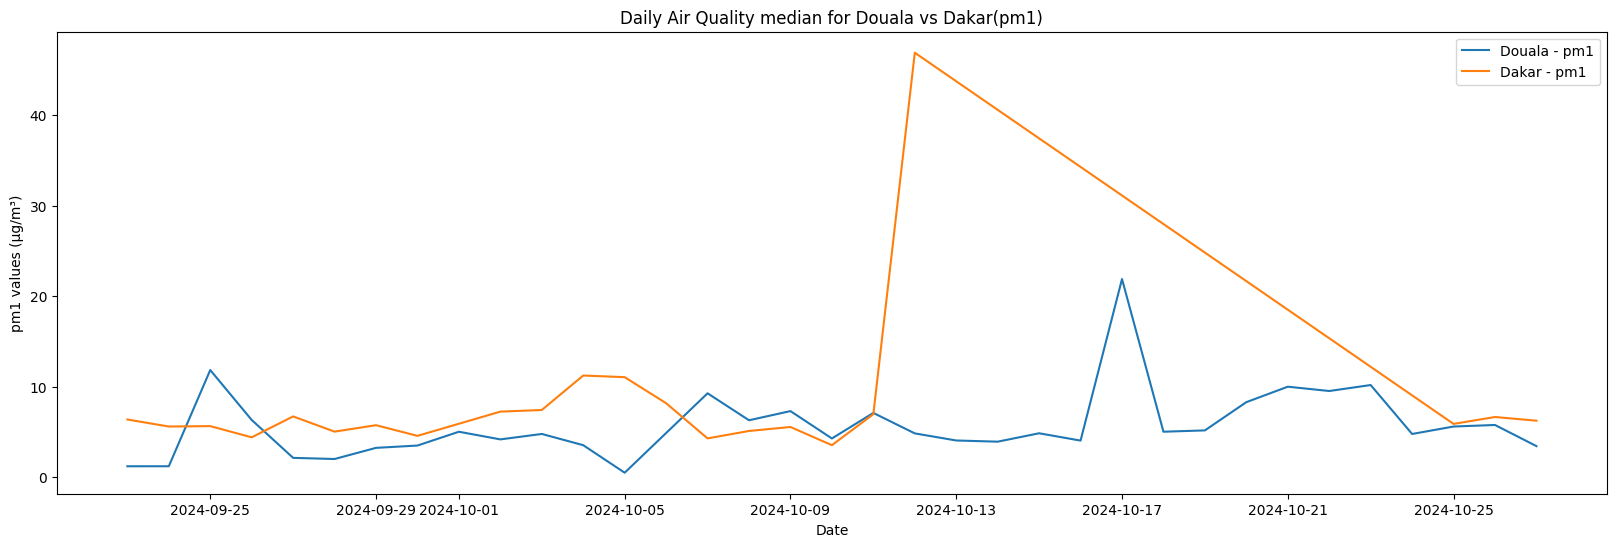

In [50]:
plt.figure(figsize=(20, 6))
plt.plot(douala_group_date_median['pm1'], label='Douala - pm1')
plt.plot(dakar_group_date_median['pm1'], label='Dakar - pm1')
plt.title('Daily Air Quality median for Douala vs Dakar(pm1)')
plt.xlabel('Date')
plt.ylabel('pm1 values (µg/m³)')
plt.legend()
plt.show()

Most of the time Dakar pm1 is greater than the one of Douala

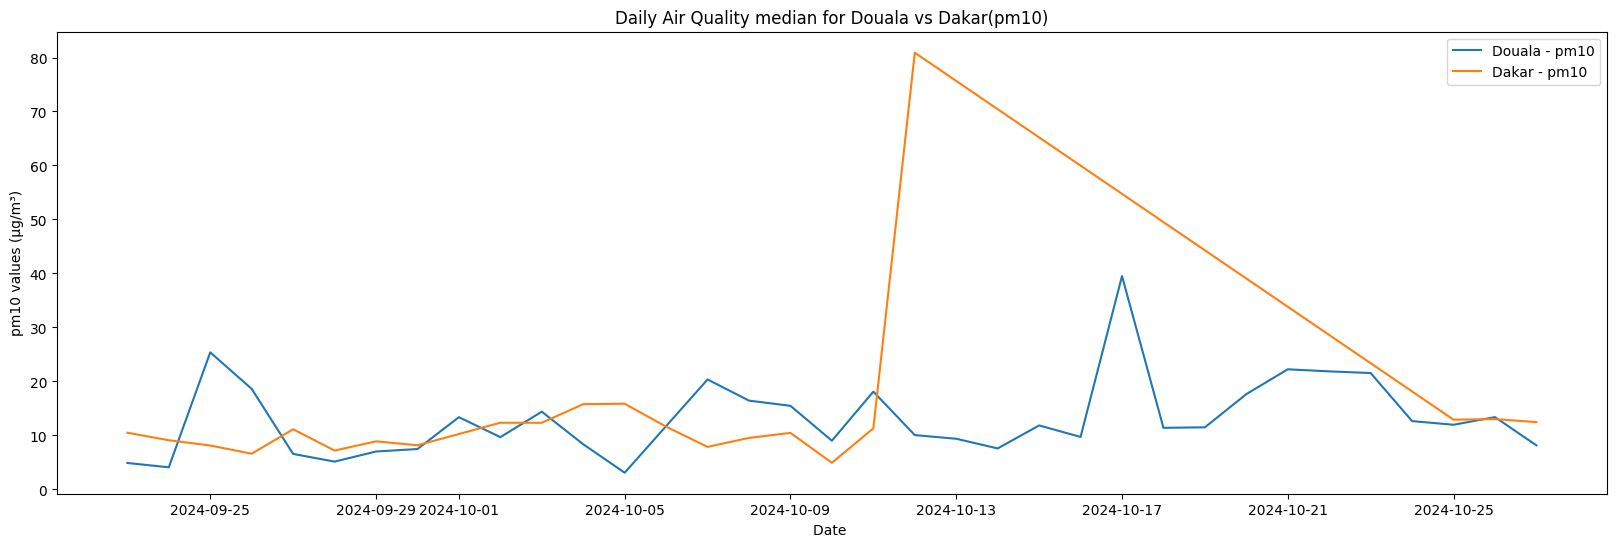

In [51]:
plt.figure(figsize=(20, 6))
plt.plot(douala_group_date_median['pm10'], label='Douala - pm10')
plt.plot(dakar_group_date_median['pm10'], label='Dakar - pm10')
plt.title('Daily Air Quality median for Douala vs Dakar(pm10)')
plt.xlabel('Date ')
plt.ylabel('pm10 values (µg/m³)')
plt.legend()
plt.show()

Most of the time Dakar pm10 is greater than the one of Douala

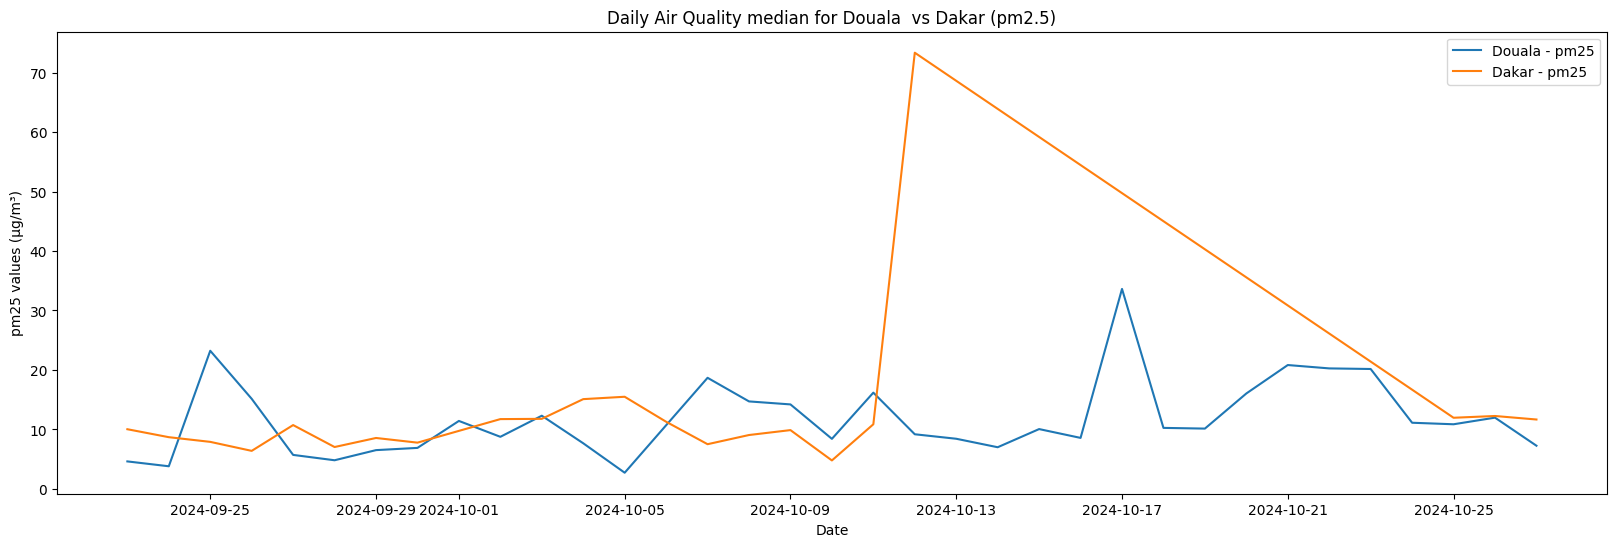

In [52]:
plt.figure(figsize=(20, 6))
plt.plot(douala_group_date_median['pm25'], label='Douala - pm25')
plt.plot(dakar_group_date_median['pm25'], label='Dakar - pm25')
plt.title('Daily Air Quality median for Douala  vs Dakar (pm2.5)' )
plt.xlabel('Date')
plt.ylabel('pm25 values (µg/m³)')
plt.legend()
plt.show()

Most of the time Dakar pm2.5 is greater than the one of Douala

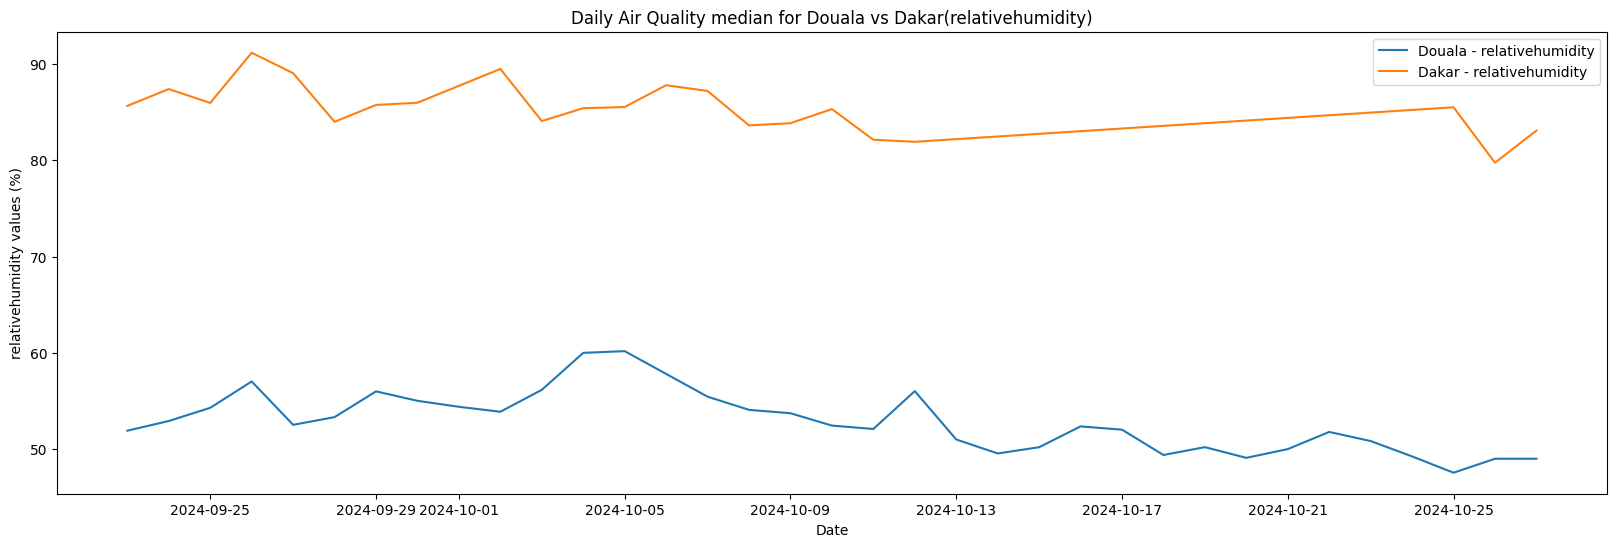

In [53]:
plt.figure(figsize=(20, 6))
plt.plot(douala_group_date_median['relativehumidity'], label='Douala - relativehumidity')
plt.plot(dakar_group_date_median['relativehumidity'], label='Dakar - relativehumidity')
plt.title('Daily Air Quality median for Douala vs Dakar(relativehumidity)')
plt.xlabel('Date')
plt.ylabel('relativehumidity values (%)')
plt.legend()
plt.show()

Here we notice that the datas do not match with real life observations because the humidity of douala is much more higher, all the more so as the climate in Douala is 
tropical and humid while that in Dakar is tropical and arid. 

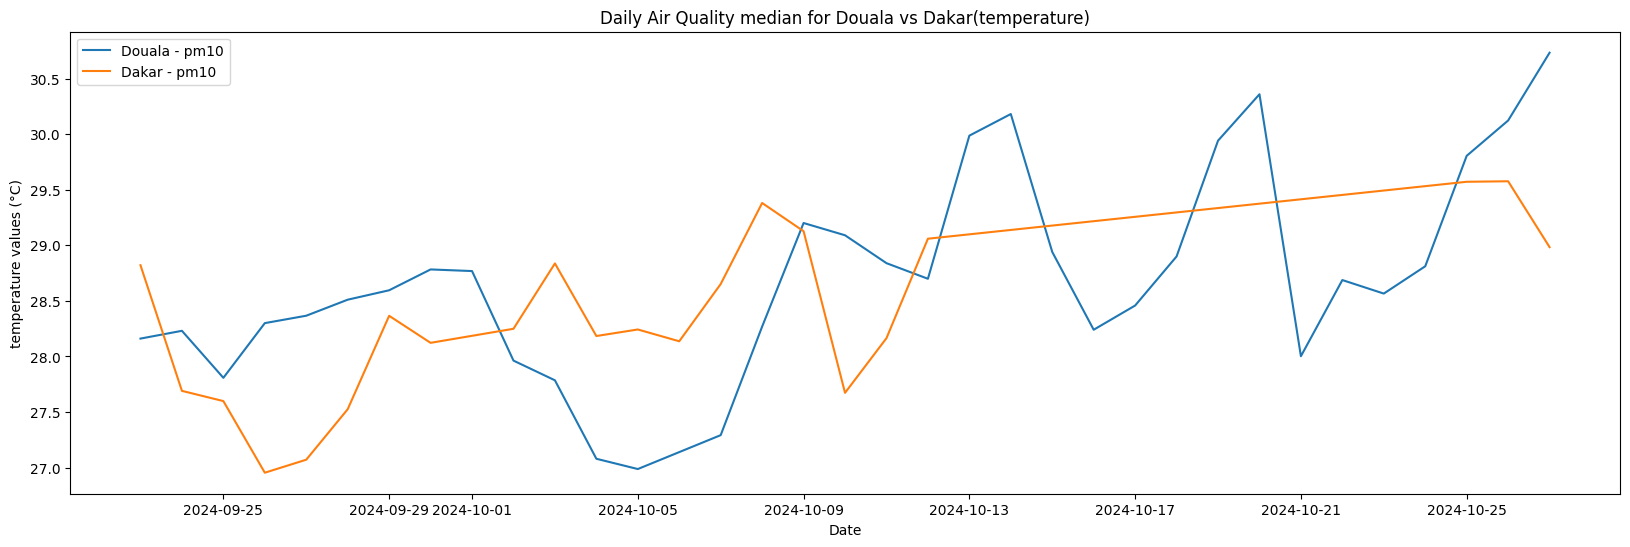

In [54]:
plt.figure(figsize=(20, 6))
plt.plot(douala_group_date_median['temperature'], label='Douala - pm10')
plt.plot(dakar_group_date_median['temperature'], label='Dakar - pm10')
plt.title('Daily Air Quality median for Douala vs Dakar(temperature)')
plt.xlabel('Date')
plt.ylabel('temperature values (°C)')
plt.legend()
plt.show()

The level of temperature for both cities is fluctuating between 27° C and 30°C. In september Dakar is hotter while Douala is hotter in the first half of october. 

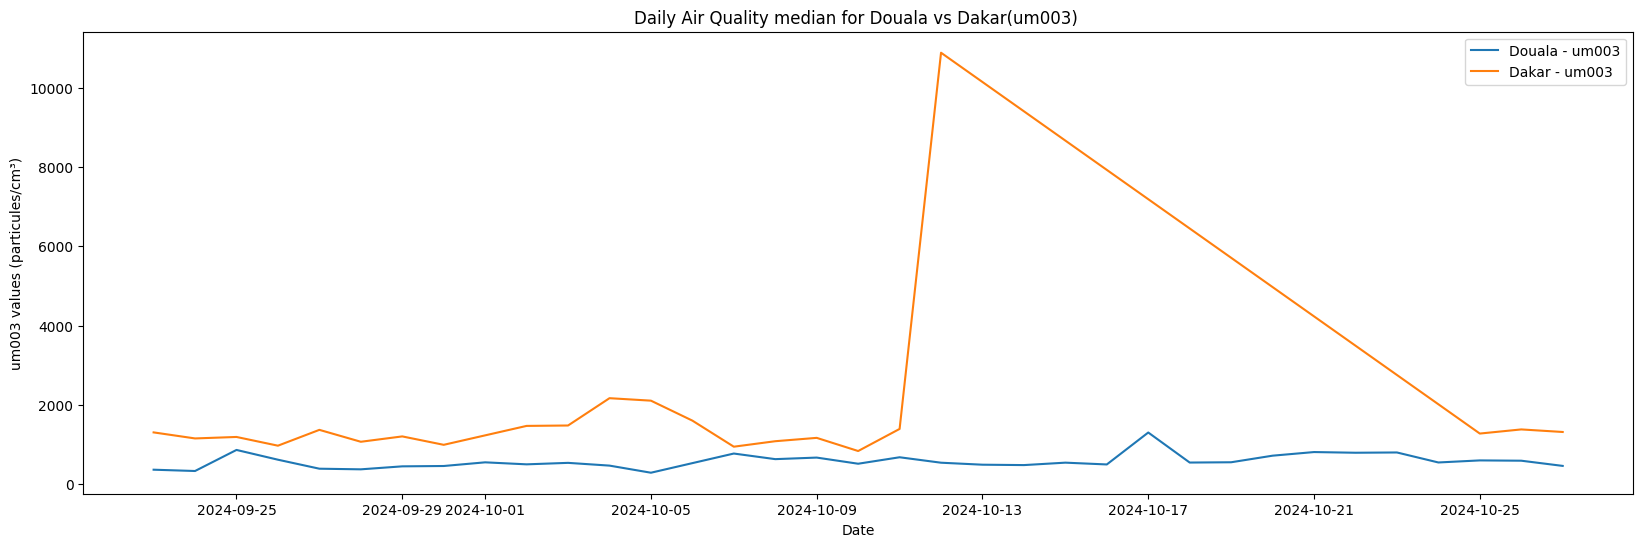

In [55]:
plt.figure(figsize=(20, 6))
plt.plot(douala_group_date_median['um003'], label='Douala - um003')
plt.plot(dakar_group_date_median['um003'], label='Dakar - um003')
plt.title('Daily Air Quality median for Douala vs Dakar(um003) ')
plt.xlabel('Date')
plt.ylabel('um003 values (particules/cm³)')
plt.legend()
plt.show()

Douala hava more particules um003 than Douala , meaning that the Dakar's air is more saturated

parameter              pm1      pm10      pm25  relativehumidity  temperature  \
parameter                                                                       
pm1               1.000000  0.978117  0.981882         -0.005086     0.031507   
pm10              0.978117  1.000000  0.998529         -0.014076     0.076998   
pm25              0.981882  0.998529  1.000000         -0.009159     0.069273   
relativehumidity -0.005086 -0.014076 -0.009159          1.000000    -0.758217   
temperature       0.031507  0.076998  0.069273         -0.758217     1.000000   
um003             0.989610  0.985417  0.986363         -0.014110     0.037675   

parameter            um003  
parameter                   
pm1               0.989610  
pm10              0.985417  
pm25              0.986363  
relativehumidity -0.014110  
temperature       0.037675  
um003             1.000000  


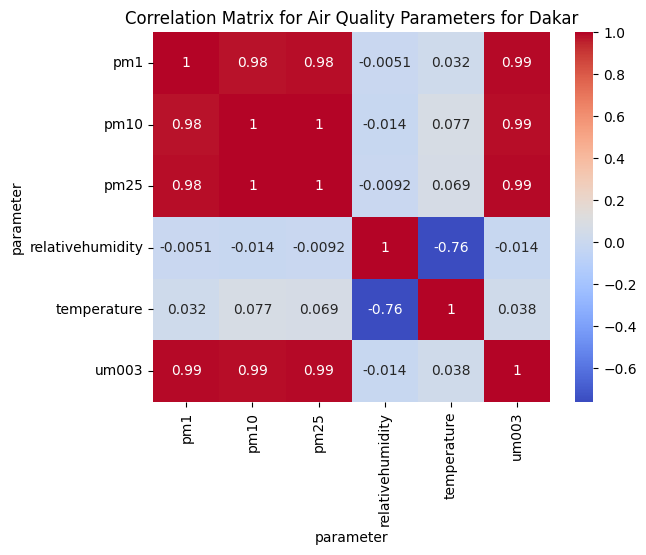

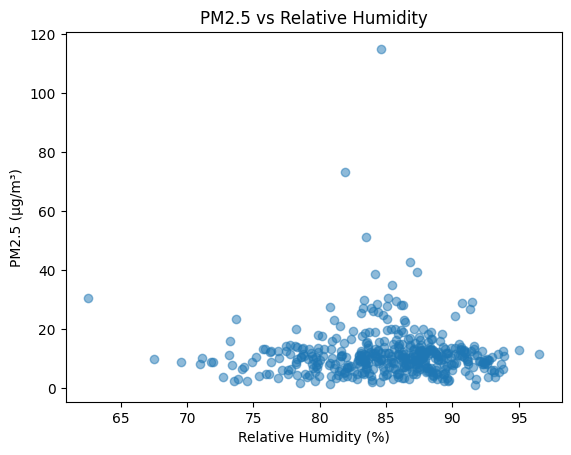

In [56]:
# We compute correlations
correlation_matrix = group_dakar[['pm1','pm10','pm25', 'relativehumidity', 'temperature', 'um003']].corr()
print(correlation_matrix)

# Visualization of correlations
import seaborn as sns
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix for Air Quality Parameters for Dakar')
plt.show()

# Scatter plot exemple : PM2.5 vs Relative himidity
plt.scatter(group_dakar['relativehumidity'], group_dakar['pm25'], alpha=0.5)
plt.xlabel('Relative Humidity (%)')
plt.ylabel('PM2.5 (µg/m³)')
plt.title('PM2.5 vs Relative Humidity')
plt.show()

There is a high positive correlation between pm2.5 and um003 meaning that when pm2.5 is increasing, rum003 particules increase too. There is also a high negative correlation 
between temperature and relative humidity so when the temperature increases, the relative humidity decreases. And it is obvious to have total correlation between pm1, pm2.5 and pm10 because if a particule weight is less than 1µg or 2.5µg, it is obtiously less than 10µg.

parameter             pm25  relativehumidity  temperature     um003
parameter                                                          
pm25              1.000000         -0.048047    -0.044661  0.976084
relativehumidity -0.048047          1.000000     0.041355 -0.055479
temperature      -0.044661          0.041355     1.000000 -0.040344
um003             0.976084         -0.055479    -0.040344  1.000000


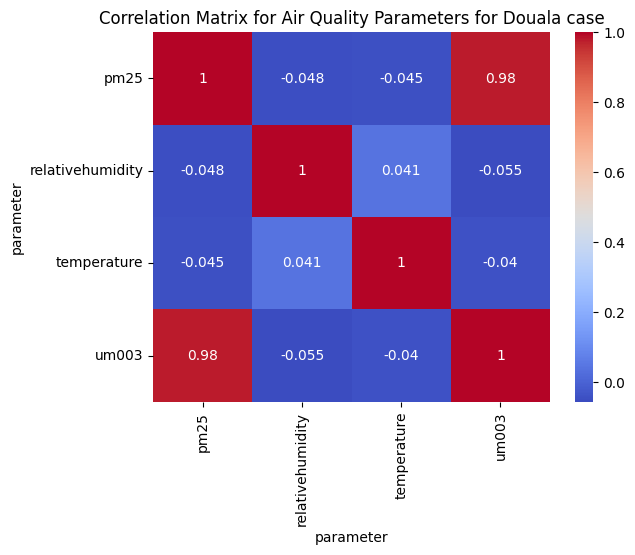

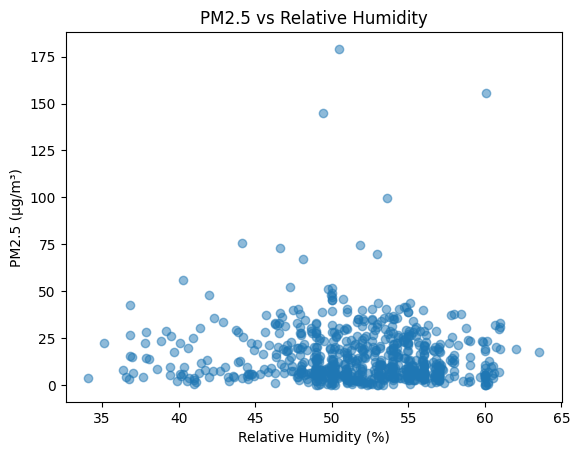

In [57]:
# We compute correlations
correlation_matrix2 = group_douala[['pm25', 'relativehumidity', 'temperature', 'um003']].corr()
print(correlation_matrix2)

# Visualization of correlations
import seaborn as sns
sns.heatmap(correlation_matrix2, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix for Air Quality Parameters for Douala case')
plt.show()

# Scatter plot exemple : PM2.5 vs Relative humidity
plt.scatter(group_douala['relativehumidity'], group_douala['pm25'], alpha=0.5)
plt.xlabel('Relative Humidity (%)')
plt.ylabel('PM2.5 (µg/m³)')
plt.title('PM2.5 vs Relative Humidity')
plt.show()

There is a high positive correlation between pm2.5 and um003 meaning that when pm2.5 is increasing

# Conclusion

At the end of our study, Dakar appears to be slightly more polluted in terms of ultrafine particles (um003) and PM1, while Douala has slightly higher concentrations of PM10 and PM2.5. If pollution by ultrafine particles is considered critical for air quality, Dakar can be considered the most polluted city in this case. Air pollution can lead to numerous illnesses, including respiratory diseases, cardiovascular diseases and other health problems. the establishment of an early warning system that will enable people to take appropriate protective measures quickly:
* promote public transport such as the TER (Regional Express Train) and the BRT (Bus Rapid Transit) 
* renewing the car fleet with less polluting vehicles;
* Planting trees

# References

* OpenAQ [https://openaq.org/]
* the regulatory threshold table [ecologie˙normes˙seuils].
* World Health Organization [https://www.who.int/news-room/fact-sheets/detail/ambient-(outdoor)-air-quality-and-health?gad_source=1&gclid=Cj0KCQjwsoe5BhDiARIsAOXVoUsHLKXqdj-vJhzVZNvJQXVNZd46pag1YNsIqCN7_qVHloBfq3FlGRYaAtmnEALw_wcB]
* European Environmental Agency [https://www.eea.europa.eu/publications/status-of-air-quality-in-Europe-2022/europes-air-quality-status-2022/world-health-organization-who-air]